# Content and Objective

+ Show that short pulses act "Dirac-like"
+ Method: Get impulse response and show that convolution with short rectangle essentially results in the same output

In [14]:
# importing
import numpy as np
import scipy.signal
import scipy as sp

import matplotlib.pyplot as plt
import matplotlib

# showing figures inline
%matplotlib inline

In [15]:
# plotting options 
font = {'size'   : 30}
plt.rc('font', **font)
plt.rc('text', usetex=False)

matplotlib.rc('figure', figsize=(30, 8) )

In [16]:
# define normalized RC value
RC = 1

In [17]:
# sample time and impulse response
t_sample = 0.01
t = np.arange( 0, 10, t_sample)

g = 1/RC * np.exp( -t/RC)

Text(0, 0.5, '$g(t)$')

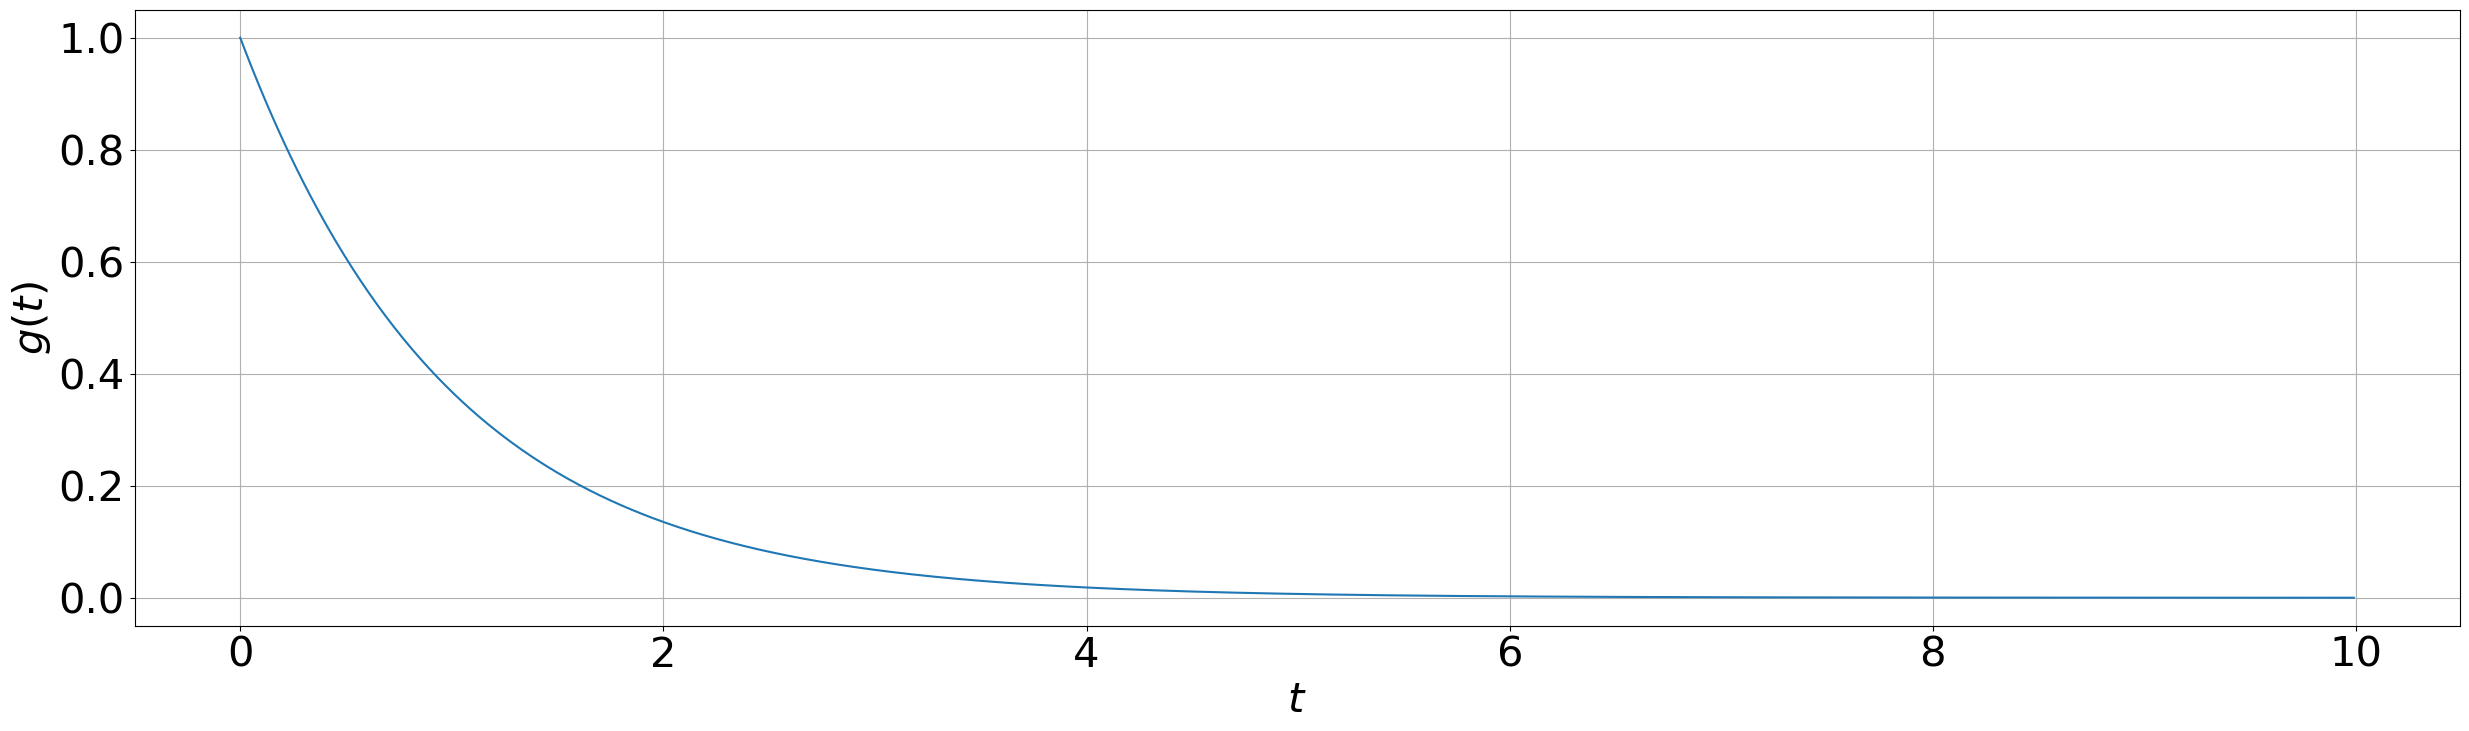

In [18]:
plt.plot( t, g )
plt.grid(True)
plt.xlabel('$t$')
plt.ylabel('$g(t)$')

In [19]:
# define rectangular being significantly shorter than time constant 
x = np.zeros_like( t )
x[ : int( RC / t_sample / 10  ) ] = 1

# get output by convolution
y = np.convolve( g, x )

In [20]:
# normalize all signals as to not taking care about energies
x /= np.max( x )
g /= np.max( g )
y /= np.max( y )

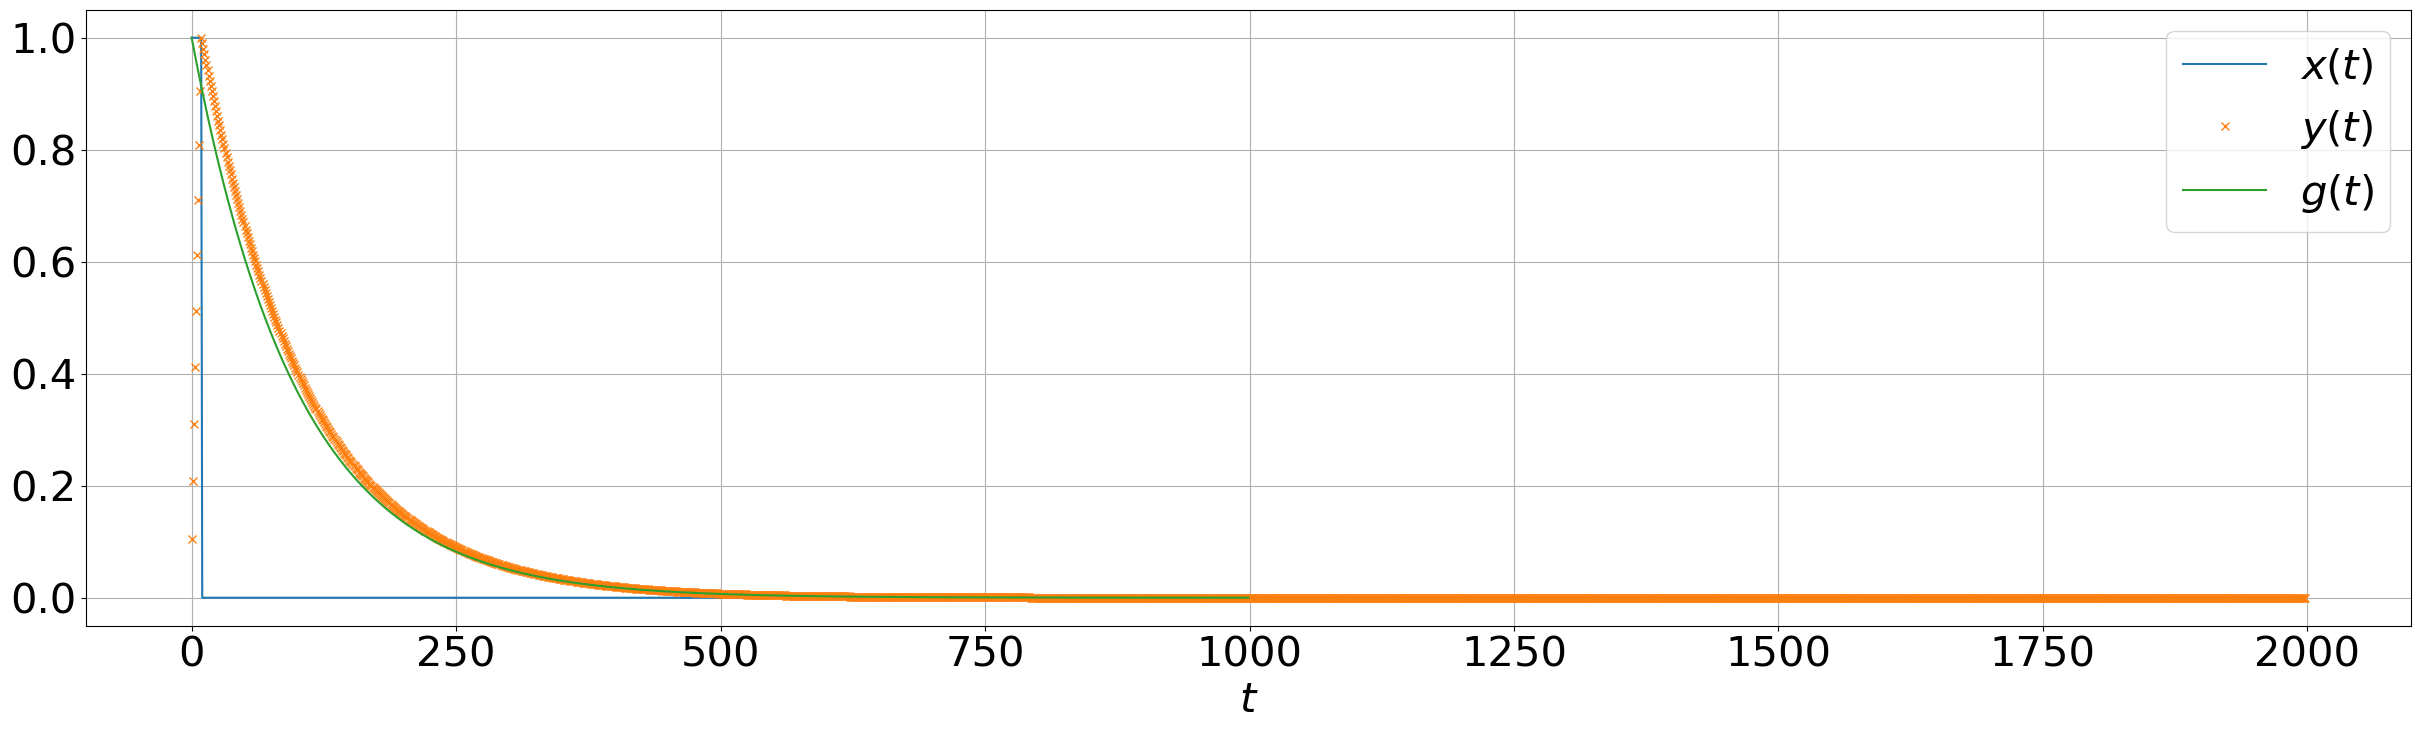

In [21]:

plt.plot( x ,label='$x(t)$')
plt.plot( y , 'x', label='$y(t)$')
plt.plot( g ,label='$g(t)$')
plt.grid( True ) 

plt.xlabel('$t$')
plt.legend( loc='best')

# Now Apply Fourier Transform to Get Frequency Response

In [22]:
# get Fourier transform
G = np.fft.fft( g )
Y = np.fft.fft( y )

# define frequency axis (not discussed in the lecture up-to-now)
f_g = np.linspace( - 1 / ( 2 * t_sample), 1 / ( 2 * t_sample ), len(G) )
f_y = np.linspace( - 1 / ( 2 * t_sample), 1 / ( 2 * t_sample ), len(Y) )

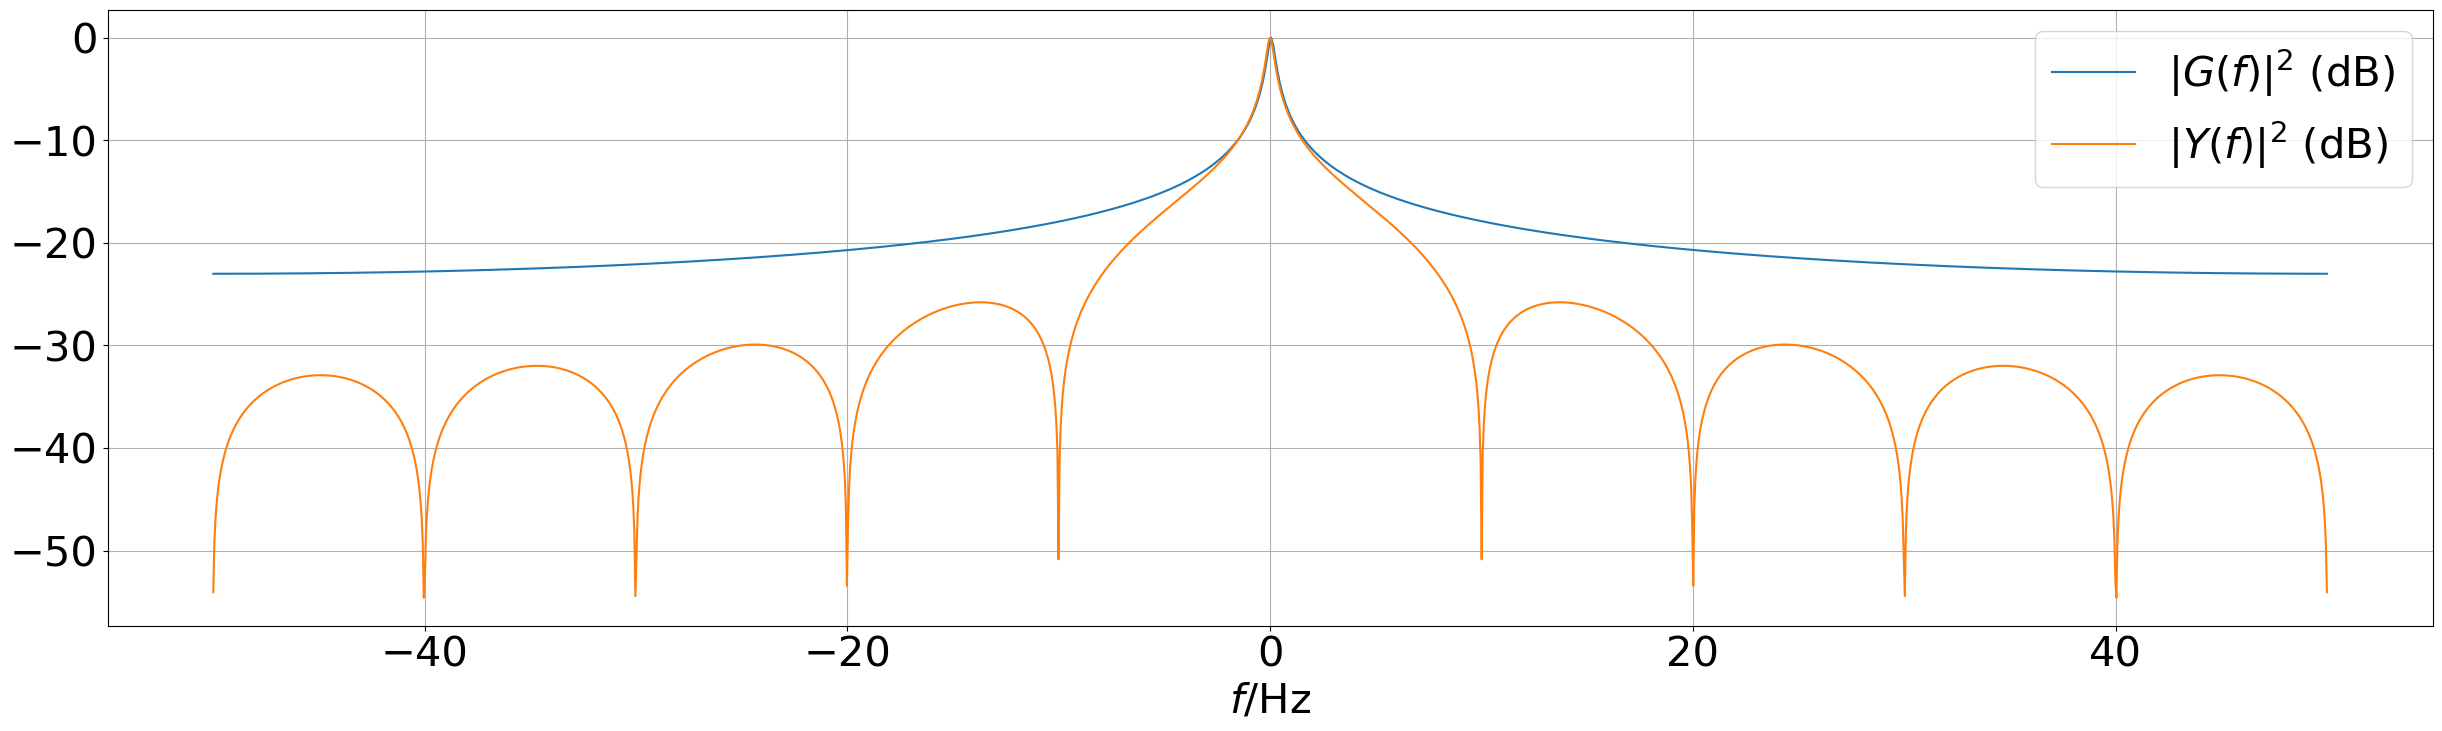

In [26]:
# now "dB-it"
plt.plot( f_g, 10*np.log10( np.abs( np.fft.fftshift( G ) ) / np.max( np.abs( G ) ) ), label='$|G(f)|^2$ (dB)' )
plt.plot( f_y, 10*np.log10( np.abs( np.fft.fftshift( Y ) ) / np.max( np.abs( Y ) ) ), label='$|Y(f)|^2$ (dB)' )

plt.grid( True )
plt.xlabel('$f/\\mathrm{Hz}$')
plt.legend()